# 13 — Hybrid Public + Clinical Training Experiment

This notebook tests one final strategy before synthesis: add a patient/encounter-group-safe 50% clinical subset into the public training pool **before augmentation**, apply the carried-forward `combo_affine_vignette_blur` virtual synthetic add-back recipe, train one U-Net++/ResNet18 model for 25 epochs, and evaluate on the remaining held-out 50% clinical patient groups.

This is not a Notebook 09 grid search. It uses one recipe only. The held-out clinical half is not used for training, augmentation, validation, checkpoint selection, or tuning.

In [1]:
# 13.01 — Imports

from __future__ import annotations

import copy
import math
import os
import platform
import sys
import time
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch.utils.data import Dataset


In [2]:
# 13.02 — Project root and source path setup

def find_project_root(start: Path | None = None) -> Path:
    current = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not find repository root containing .git.")


PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


In [3]:
# 13.03 — Project package imports

from glaucoma_segmentation.augmentation import (
    build_virtual_synthetic_expansion_dataset,
    combined_online_augmentation_components,
    summarize_virtual_synthetic_expansion,
)
from glaucoma_segmentation.clinical import (
    ClinicalDerivedMaskDataset,
    evaluate_model_on_clinical_loader,
    summarize_image_level_clinical_metrics,
    summarize_patient_weighted_clinical_metrics,
)
from glaucoma_segmentation.data.dataloaders import (
    make_segmentation_dataloader,
    make_segmentation_datasets,
)
from glaucoma_segmentation.nets.losses import DiceCELoss
from glaucoma_segmentation.nets.model_factory import build_model
from glaucoma_segmentation.training.train_loop import (
    extract_images_and_masks,
    model_forward,
    run_one_epoch_with_progress,
)
from glaucoma_segmentation.utils.device import device_summary_dict, get_device
from glaucoma_segmentation.utils.seed import seed_everything


<HOME>/.conda/envs/glaucoma-capstone/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# 13.04 — Paths and required input checks

REPORTS = PROJECT_ROOT / "reports"
TRAINING = REPORTS / "training"
AUDIT = REPORTS / "data_audit"
TRAINING.mkdir(parents=True, exist_ok=True)
AUDIT.mkdir(parents=True, exist_ok=True)

PUBLIC_MANIFEST = PROJECT_ROOT / "data/processed/manifests/combined_segmentation_manifest_with_splits.csv"
CLINICAL_MANIFEST = PROJECT_ROOT / "data/interim/private_clinical_generalization/clinical_psd_derived_mask_manifest_private.csv"
N10_SUMMARY = TRAINING / "long_training_selected_public_summary.csv"
N10_CKPT = PROJECT_ROOT / "data/interim/private_model_checkpoints/notebook_10/long_training_selected_public_best_state_private.pt"

PRIVATE_DIR = PROJECT_ROOT / "data/interim/private_hybrid_public_clinical_training"
PRIVATE_CKPT_DIR = PROJECT_ROOT / "data/interim/private_model_checkpoints/notebook_13"
PRIVATE_DIR.mkdir(parents=True, exist_ok=True)
PRIVATE_CKPT_DIR.mkdir(parents=True, exist_ok=True)

PRIVATE_SPLIT = PRIVATE_DIR / "hybrid_public_clinical_split_manifest_private.csv"
PRIVATE_METRICS = PRIVATE_DIR / "hybrid_public_clinical_image_level_metrics_private.csv"

SPLIT_SUMMARY = AUDIT / "hybrid_public_clinical_split_summary.csv"
DATASET_SUMMARY = AUDIT / "hybrid_public_clinical_dataset_summary.csv"
PLAN = TRAINING / "hybrid_public_clinical_training_plan.csv"
HISTORY = TRAINING / "hybrid_public_clinical_training_history.csv"
METADATA = TRAINING / "hybrid_public_clinical_run_metadata.csv"
VAL_SUMMARY = TRAINING / "hybrid_public_clinical_validation_summary.csv"
PUBLIC_TEST = TRAINING / "hybrid_public_clinical_public_test_summary.csv"
CLINICAL_TEST = TRAINING / "hybrid_public_clinical_clinical_test_summary.csv"
PATIENT_TEST = TRAINING / "hybrid_public_clinical_patient_weighted_summary.csv"
COMPARISON = TRAINING / "hybrid_public_clinical_comparison_summary.csv"
FINAL_SUMMARY = TRAINING / "hybrid_public_clinical_final_summary.csv"

missing = [
    str(path.relative_to(PROJECT_ROOT))
    for path in [PUBLIC_MANIFEST, CLINICAL_MANIFEST, N10_SUMMARY, N10_CKPT]
    if not path.exists()
]
if missing:
    raise FileNotFoundError(f"Missing required inputs: {missing}")


In [5]:
# 13.05 — Hybrid experiment configuration

SEED = 42
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 8
EPOCHS = 25
LR = 1e-4
WD = 1e-4
NUM_CLASSES = 3
NUM_WORKERS = min(2, max(1, (os.cpu_count() or 2) - 1))
PIN_MEMORY = torch.cuda.is_available()

STRATEGY = "combo_affine_vignette_blur"
COMPONENTS = ";".join(combined_online_augmentation_components(STRATEGY))
MEANINGFUL_DICE_DELTA = 0.005

FORCE_RERUN = False
RERUN_ZERO_SHOT = False

ZERO = "zero_shot_notebook10_on_hybrid50_clinical_holdout"
HYBRID = "hybrid_public_plus_50pct_clinical_preaugmentation"
RUN_NAME = "hybrid_unetplusplus_resnet18_combo_affine_vignette_blur_public_plus_50pct_clinical_256px_25epoch"

seed_everything(SEED, deterministic=False)
DEVICE = get_device()
DEVICE_INFO = device_summary_dict(DEVICE)

print(f"Project root: {PROJECT_ROOT.name}")
print(f"Python executable: {sys.executable}")
print(f"Python version: {platform.python_version()}")
print(f"Device: {DEVICE}")

display(
    pd.DataFrame(
        [
            {
                "seed": SEED,
                "image_size": IMAGE_SIZE,
                "batch_size": BATCH_SIZE,
                "epochs": EPOCHS,
                "learning_rate": LR,
                "weight_decay": WD,
                "num_workers": NUM_WORKERS,
                "strategy": STRATEGY,
                "components": COMPONENTS,
                "clinical_rows_added_pre_augmentation": True,
                "force_rerun": FORCE_RERUN,
                "rerun_zero_shot": RERUN_ZERO_SHOT,
            }
            | DEVICE_INFO
        ]
    )
)


Project root: Automated-Glaucoma-Screening-Using-AI-Enhanced-Ophthalmoscopy
Python executable: <HOME>/.conda/envs/glaucoma-capstone/bin/python
Python version: 3.11.15
Device: cuda


,seed,image_size,batch_size,epochs,learning_rate,weight_decay,num_workers,strategy,components,clinical_rows_added_pre_augmentation,force_rerun,rerun_zero_shot,device,device_type,name,cuda_available,cuda_device_count,mps_available
0,42,"(256, 256)",8,25,0.0001,0.0001,2,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,True,False,False,cuda,cuda,NVIDIA RTX A6000,True,1,False


## Hybrid experiment design

The clinical training half is added to the public training pool before virtual synthetic expansion. The held-out clinical half is never used for training, augmentation, validation, checkpoint selection, or tuning.

In [6]:
# 13.06 — Load Notebook 10 reference model context

n10 = pd.read_csv(N10_SUMMARY).iloc[0].to_dict()
n10_ckpt = torch.load(N10_CKPT, map_location="cpu")
n10_state = copy.deepcopy(n10_ckpt["model_state_dict"])

MODEL = str(n10["model_name"])
ENCODER = str(n10["encoder_name"])
N10_EPOCH = int(n10["best_epoch_by_val_mean_foreground_dice"])

if MODEL != "unetplusplus" or ENCODER != "resnet18":
    raise RuntimeError(f"Unexpected Notebook 10 model: {MODEL}/{ENCODER}")


def add_public_flags(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    frame["contains_private_paths"] = False
    frame["contains_sample_hashes"] = False
    frame["contains_patient_hashes"] = False
    return frame


/tmp/ipykernel_561127/1475534197.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  n10_ckpt = torch.load(N10_CKPT, map_location="cpu")


In [7]:
# 13.07 — Build 50/50 clinical patient-group split

clinical = pd.read_csv(CLINICAL_MANIFEST)
ready = clinical.loc[clinical["mask_ready"].astype(bool)].copy()

if len(ready) != 59:
    raise RuntimeError(f"Expected 59 mask-ready clinical rows, found {len(ready)}")

ready["patient_hash"] = ready["patient_hash"].astype(str)
ready["eye"] = ready["eye"].astype(str).str.upper().replace({"NAN": "UNKNOWN"})

groups = sorted(ready["patient_hash"].unique().tolist())
if len(groups) != 20:
    raise RuntimeError(f"Expected 20 clinical groups, found {len(groups)}")

rng = np.random.default_rng(SEED + 1300)
rng.shuffle(groups)

train_groups = set(groups[:10])
test_groups = set(groups[10:])

if train_groups & test_groups:
    raise RuntimeError("Clinical split leakage detected")

ready["hybrid_public_clinical_split"] = "unused"
ready.loc[ready["patient_hash"].isin(train_groups), "hybrid_public_clinical_split"] = "hybrid_train"
ready.loc[ready["patient_hash"].isin(test_groups), "hybrid_public_clinical_split"] = "heldout_clinical_test"
ready.to_csv(PRIVATE_SPLIT, index=False)

clinical_train_frame = ready.loc[ready["hybrid_public_clinical_split"] == "hybrid_train"].copy()
clinical_test_frame = ready.loc[ready["hybrid_public_clinical_split"] == "heldout_clinical_test"].copy()


def split_row(frame: pd.DataFrame, split: str, used_for: str) -> dict[str, object]:
    eyes = frame["eye"].value_counts().to_dict()
    return {
        "split": split,
        "used_for": used_for,
        "rows": int(len(frame)),
        "patient_groups": int(frame["patient_hash"].nunique()),
        "eye_od_rows": int(eyes.get("OD", 0)),
        "eye_os_rows": int(eyes.get("OS", 0)),
        "eye_unknown_rows": int(eyes.get("UNKNOWN", 0)),
        "split_by_patient_or_encounter_group": True,
        "contains_raw_paths": False,
        "contains_sample_hashes": False,
        "contains_patient_hashes": False,
    }


split_summary = pd.DataFrame(
    [
        split_row(
            clinical_train_frame,
            "hybrid_train_clinical_50pct_groups",
            "added_to_public_train_before_augmentation",
        ),
        split_row(
            clinical_test_frame,
            "heldout_clinical_test_50pct_groups",
            "heldout_clinical_test_only",
        ),
    ]
)
split_summary.to_csv(SPLIT_SUMMARY, index=False)


In [8]:
# 13.08 — Load public and clinical datasets

public = make_segmentation_datasets(
    PUBLIC_MANIFEST,
    splits=("train", "val", "test"),
    image_size=IMAGE_SIZE,
    validate_paths=True,
    validate_masks=True,
)

if public.train is None or public.val is None or public.test is None:
    raise RuntimeError("Missing public train/val/test datasets")

if (len(public.train), len(public.val), len(public.test)) != (1911, 725, 722):
    raise RuntimeError("Unexpected public split sizes")

clinical_train = ClinicalDerivedMaskDataset(
    clinical_train_frame.copy(),
    project_root=PROJECT_ROOT,
    image_size=IMAGE_SIZE,
    require_mask_ready=True,
    validate_paths=True,
)
clinical_test = ClinicalDerivedMaskDataset(
    clinical_test_frame.copy(),
    project_root=PROJECT_ROOT,
    image_size=IMAGE_SIZE,
    require_mask_ready=True,
    validate_paths=True,
)


In [9]:
# 13.09 — Construct hybrid pre-augmentation dataset

class NormalizedDataset(Dataset):
    def __init__(self, dataset: Dataset, source: str) -> None:
        self.dataset = dataset
        self.source = source

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, idx: int) -> dict[str, object]:
        item = self.dataset[idx]
        if isinstance(item, dict):
            image = item.get("image", item.get("images"))
            mask = item.get("mask", item.get("masks"))
        else:
            image, mask = item[0], item[1]
        return {"image": image, "mask": mask, "source_domain": self.source}


class HybridDataset(Dataset):
    def __init__(self, datasets: list[Dataset], names: list[str]) -> None:
        self.datasets = datasets
        self.names = names
        self.lengths = [len(dataset) for dataset in datasets]
        self.cumulative = np.cumsum(self.lengths).tolist()

    def __len__(self) -> int:
        return int(self.cumulative[-1])

    def __getitem__(self, idx: int) -> dict[str, object]:
        dataset_index = int(np.searchsorted(self.cumulative, int(idx), side="right"))
        previous = 0 if dataset_index == 0 else self.cumulative[dataset_index - 1]
        item = dict(self.datasets[dataset_index][int(idx) - previous])
        item["hybrid_component"] = self.names[dataset_index]
        return item


hybrid_base = HybridDataset(
    [
        NormalizedDataset(public.train, "public_train"),
        NormalizedDataset(clinical_train, "clinical_train"),
    ],
    ["public_train", "clinical_train"],
)

hybrid_train = build_virtual_synthetic_expansion_dataset(
    hybrid_base,
    strategy_names=[STRATEGY],
    copy_count=1,
    base_seed=SEED,
    include_original=True,
    add_metadata=True,
)

virtual_summary = summarize_virtual_synthetic_expansion(hybrid_train)


In [10]:
# 13.10 — Save dataset summary and training plan

dataset_summary = pd.DataFrame(
    [
        {
            "dataset_role": "hybrid_base_train_before_virtual_synthetic_expansion",
            "public_train_rows": len(public.train),
            "clinical_train_rows": len(clinical_train),
            "clinical_train_groups": int(clinical_train_frame["patient_hash"].nunique()),
            "hybrid_base_rows": len(hybrid_base),
            "clinical_rows_added_pre_augmentation": True,
            "strategy": STRATEGY,
            "components": COMPONENTS,
            "heldout_clinical_test_rows": len(clinical_test),
            "heldout_clinical_test_groups": int(clinical_test_frame["patient_hash"].nunique()),
            "public_validation_rows": len(public.val),
            "public_test_rows": len(public.test),
            "materializes_synthetic_files": False,
        },
        {
            "dataset_role": "hybrid_virtual_train_after_original_add_back",
            "public_train_rows": len(public.train),
            "clinical_train_rows": len(clinical_train),
            "clinical_train_groups": int(clinical_train_frame["patient_hash"].nunique()),
            "hybrid_base_rows": len(hybrid_base),
            **virtual_summary,
            "clinical_rows_added_pre_augmentation": True,
            "strategy": STRATEGY,
            "components": COMPONENTS,
            "heldout_clinical_test_rows": len(clinical_test),
            "heldout_clinical_test_groups": int(clinical_test_frame["patient_hash"].nunique()),
            "public_validation_rows": len(public.val),
            "public_test_rows": len(public.test),
            "materializes_synthetic_files": False,
        },
    ]
)
dataset_summary = add_public_flags(dataset_summary)
dataset_summary.to_csv(DATASET_SUMMARY, index=False)

plan = pd.DataFrame(
    [
        {
            "condition": ZERO,
            "run_name": str(n10["run_name"]),
            "model_training_mode": "none_zero_shot_same_clinical_holdout",
            "clinical_rows_added_pre_augmentation": False,
            "epochs": 0,
            "heldout_clinical_test_rows": len(clinical_test),
            "heldout_clinical_test_groups": int(clinical_test_frame["patient_hash"].nunique()),
            "clinical_test_used_for_selection": False,
        },
        {
            "condition": HYBRID,
            "run_name": RUN_NAME,
            "model_training_mode": "public_plus_clinical_pre_augmentation_virtual_synthetic_add_back",
            "public_training_rows": len(public.train),
            "clinical_training_rows": len(clinical_train),
            "clinical_training_groups": int(clinical_train_frame["patient_hash"].nunique()),
            "clinical_rows_added_pre_augmentation": True,
            "hybrid_base_train_rows": len(hybrid_base),
            "hybrid_virtual_train_rows": len(hybrid_train),
            "public_validation_rows": len(public.val),
            "public_test_rows": len(public.test),
            "heldout_clinical_test_rows": len(clinical_test),
            "heldout_clinical_test_groups": int(clinical_test_frame["patient_hash"].nunique()),
            "strategy": STRATEGY,
            "components": COMPONENTS,
            "epochs": EPOCHS,
            "learning_rate": LR,
            "weight_decay": WD,
            "selection_metric": "public_validation_mean_foreground_dice",
            "clinical_test_used_for_selection": False,
        },
    ]
)
plan = add_public_flags(plan)
plan.to_csv(PLAN, index=False)

display(split_summary)
display(dataset_summary)
display(plan)

print(f"Private split saved: {PRIVATE_SPLIT.relative_to(PROJECT_ROOT)}")


,split,used_for,rows,patient_groups,eye_od_rows,eye_os_rows,eye_unknown_rows,split_by_patient_or_encounter_group,contains_raw_paths,contains_sample_hashes,contains_patient_hashes
0,hybrid_train_clinical_50pct_groups,added_to_public_train_before_augmentation,21,10,11,3,7,True,False,False,False
1,heldout_clinical_test_50pct_groups,heldout_clinical_test_only,38,10,10,10,18,True,False,False,False


,dataset_role,public_train_rows,clinical_train_rows,clinical_train_groups,hybrid_base_rows,clinical_rows_added_pre_augmentation,strategy,components,heldout_clinical_test_rows,heldout_clinical_test_groups,...,original_rows_exposed,synthetic_rows_exposed,total_rows_exposed,base_seed,include_original,strategies,copy_counts,contains_private_paths,contains_sample_hashes,contains_patient_hashes
0,hybrid_base_train_before_virtual_synthetic_exp...,1911,21,10,1932,True,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,38,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False
1,hybrid_virtual_train_after_original_add_back,1911,21,10,1932,True,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,38,10,...,1932.0,1932.0,3864.0,42.0,True,combo_affine_vignette_blur,1,False,False,False


,condition,run_name,model_training_mode,clinical_rows_added_pre_augmentation,epochs,heldout_clinical_test_rows,heldout_clinical_test_groups,clinical_test_used_for_selection,public_training_rows,clinical_training_rows,...,public_validation_rows,public_test_rows,strategy,components,learning_rate,weight_decay,selection_metric,contains_private_paths,contains_sample_hashes,contains_patient_hashes
0,zero_shot_notebook10_on_hybrid50_clinical_holdout,long_unetplusplus_resnet18_combo_affine_vignet...,none_zero_shot_same_clinical_holdout,False,0,38,10,False,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False
1,hybrid_public_plus_50pct_clinical_preaugmentation,hybrid_unetplusplus_resnet18_combo_affine_vign...,public_plus_clinical_pre_augmentation_virtual_...,True,25,38,10,False,1911.0,21.0,...,725.0,722.0,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,0.0001,0.0001,public_validation_mean_foreground_dice,False,False,False


Private split saved: data/interim/private_hybrid_public_clinical_training/hybrid_public_clinical_split_manifest_private.csv


In [11]:
# 13.11 — Helper functions

def mean_fg(disc: float, cup: float) -> float:
    return float((float(disc) + float(cup)) / 2.0)


def write_csv(path: Path, frame: pd.DataFrame) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(path, index=False)


def replace_condition(path: Path, frame: pd.DataFrame, condition: str) -> None:
    if path.exists():
        old = pd.read_csv(path)
        if "condition" in old.columns:
            old = old.loc[old["condition"].astype(str) != condition].copy()
        frame = pd.concat([old, frame], ignore_index=True, sort=False)
    write_csv(path, frame)


def condition_exists(path: Path, condition: str) -> bool:
    if not path.exists():
        return False
    frame = pd.read_csv(path)
    return "condition" in frame.columns and condition in set(frame["condition"].astype(str))


def build_fresh_model() -> torch.nn.Module:
    return build_model(
        model_name=MODEL,
        in_channels=3,
        classes=NUM_CLASSES,
        encoder_name=ENCODER,
        encoder_weights=None,
    )


def build_n10_model() -> torch.nn.Module:
    model = build_fresh_model()
    model.load_state_dict(n10_state)
    return model


def make_loaders() -> tuple[Any, Any, Any, Any]:
    train = make_segmentation_dataloader(
        hybrid_train,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
    )
    val = make_segmentation_dataloader(
        public.val,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
    )
    pub_test = make_segmentation_dataloader(
        public.test,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
    )
    cli_test = make_segmentation_dataloader(
        clinical_test,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
    )
    return train, val, pub_test, cli_test


def save_private_checkpoint(
    path: Path,
    model: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    best_metric: float,
    record: dict[str, object],
    checkpoint_type: str,
) -> None:
    payload = {
        "checkpoint_type": checkpoint_type,
        "condition": HYBRID,
        "run_name": RUN_NAME,
        "epoch": int(epoch),
        "best_metric": float(best_metric),
        "model_name": MODEL,
        "encoder_name": ENCODER,
        "strategy": STRATEGY,
        "components": COMPONENTS,
        "clinical_data_used": True,
        "clinical_rows_added_pre_augmentation": True,
        "model_state_dict": {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        },
        "optimizer_state_dict": optimizer.state_dict(),
        "validation_record": record,
    }
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(payload, path)


def evaluate_clinical(
    model: torch.nn.Module,
    condition: str,
    run_name: str,
    epoch: int | float,
    train_rows: int,
    train_groups: int,
    usage: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    _, _, _, clinical_loader = make_loaders()
    metrics = pd.DataFrame(
        evaluate_model_on_clinical_loader(
            model,
            clinical_loader,
            device=DEVICE,
            model_forward_fn=model_forward,
        )
    )
    metrics.insert(0, "condition", condition)
    metrics.insert(1, "run_name", run_name)

    condition_private = PRIVATE_DIR / f"{condition}_image_level_metrics_private.csv"
    metrics.to_csv(condition_private, index=False)

    if PRIVATE_METRICS.exists():
        old = pd.read_csv(PRIVATE_METRICS)
        old = old.loc[old["condition"].astype(str) != condition].copy()
        pd.concat([old, metrics], ignore_index=True, sort=False).to_csv(PRIVATE_METRICS, index=False)
    else:
        metrics.to_csv(PRIVATE_METRICS, index=False)

    image = summarize_image_level_clinical_metrics(metrics)
    patient = summarize_patient_weighted_clinical_metrics(metrics)

    for frame in [image, patient]:
        frame.insert(0, "condition", condition)
        frame.insert(1, "run_name", run_name)
        frame.insert(2, "model_name", MODEL)
        frame.insert(3, "encoder_name", ENCODER)
        frame.insert(4, "strategy", STRATEGY)
        frame.insert(5, "checkpoint_epoch", epoch)
        frame.insert(6, "clinical_training_rows_used", int(train_rows))
        frame.insert(7, "clinical_training_groups_used", int(train_groups))
        frame.insert(8, "heldout_clinical_test_rows", len(clinical_test))
        frame.insert(9, "heldout_clinical_test_groups", int(clinical_test_frame["patient_hash"].nunique()))
        frame.insert(10, "clinical_data_usage", usage)
        frame["clinical_test_used_for_selection"] = False
        frame["private_image_level_metrics_committed"] = False

    image = add_public_flags(image)
    patient = add_public_flags(patient)

    replace_condition(CLINICAL_TEST, image, condition)
    replace_condition(PATIENT_TEST, patient, condition)

    return image, patient


In [12]:
# 13.12 — Hybrid dataloader smoke test

smoke_loader = make_segmentation_dataloader(
    hybrid_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)
smoke_batch = next(iter(smoke_loader))
images, masks = extract_images_and_masks(smoke_batch)

smoke = pd.DataFrame(
    [
        {
            "image_shape": tuple(images.shape),
            "mask_shape": tuple(masks.shape),
            "mask_values": sorted(int(value) for value in torch.unique(masks).tolist()),
            "source_preview": list(smoke_batch.get("source_domain", []))[:8],
            "hybrid_component_preview": list(smoke_batch.get("hybrid_component", []))[:8],
        }
    ]
)
display(smoke)

if not set(smoke.loc[0, "mask_values"]).issubset({0, 1, 2}):
    raise RuntimeError("Unexpected mask values in smoke batch")


,image_shape,mask_shape,mask_values,source_preview,hybrid_component_preview
0,"(8, 3, 256, 256)","(8, 256, 256)","[0, 1, 2]","[public_train, public_train, public_train, pub...","[public_train, public_train, public_train, pub..."


In [13]:
# 13.13 — Zero-shot Notebook 10 model on held-out clinical half

if (
    condition_exists(CLINICAL_TEST, ZERO)
    and condition_exists(PATIENT_TEST, ZERO)
    and not RERUN_ZERO_SHOT
    and not FORCE_RERUN
):
    print(f"{ZERO}: existing outputs found; skipping")
    display(pd.read_csv(PATIENT_TEST).loc[lambda frame: frame["condition"].astype(str) == ZERO])
else:
    model = build_n10_model().to(DEVICE)
    model.eval()

    image, patient = evaluate_clinical(
        model,
        ZERO,
        str(n10["run_name"]),
        N10_EPOCH,
        0,
        0,
        "heldout_clinical_test_only",
    )

    metadata = add_public_flags(
        pd.DataFrame(
            [
                {
                    "condition": ZERO,
                    "run_name": str(n10["run_name"]),
                    "source_notebook": "10_long_training_selected_public_model",
                    "checkpoint_epoch": N10_EPOCH,
                    "clinical_training_rows_used": 0,
                    "clinical_training_groups_used": 0,
                    "heldout_clinical_test_rows": len(clinical_test),
                    "heldout_clinical_test_groups": int(clinical_test_frame["patient_hash"].nunique()),
                    "clinical_data_usage": "heldout_clinical_test_only",
                    "clinical_test_used_for_selection": False,
                    "total_fit_minutes": 0.0,
                    "private_checkpoint_saved": False,
                    "private_checkpoint_committed": False,
                    "private_image_level_metrics_saved": True,
                    "private_image_level_metrics_committed": False,
                }
            ]
        )
    )
    replace_condition(METADATA, metadata, ZERO)

    display(image)
    display(patient)
    display(metadata)

    del model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


,condition,run_name,model_name,encoder_name,strategy,checkpoint_epoch,clinical_training_rows_used,clinical_training_groups_used,heldout_clinical_test_rows,heldout_clinical_test_groups,...,image_weighted_cdr_abs_error_mean,image_weighted_cdr_abs_error_median,image_weighted_cdr_abs_error_std,image_weighted_cdr_abs_error_min,image_weighted_cdr_abs_error_max,clinical_test_used_for_selection,private_image_level_metrics_committed,contains_private_paths,contains_sample_hashes,contains_patient_hashes
0,zero_shot_notebook10_on_hybrid50_clinical_holdout,long_unetplusplus_resnet18_combo_affine_vignet...,unetplusplus,resnet18,combo_affine_vignette_blur,24,0,0,38,10,...,0.329826,0.290476,0.23624,0.018519,0.9375,False,False,False,False,False


,condition,run_name,model_name,encoder_name,strategy,checkpoint_epoch,clinical_training_rows_used,clinical_training_groups_used,heldout_clinical_test_rows,heldout_clinical_test_groups,...,patient_weighted_cdr_abs_error_mean,patient_weighted_cdr_abs_error_median,patient_weighted_cdr_abs_error_std,patient_weighted_cdr_abs_error_min,patient_weighted_cdr_abs_error_max,clinical_test_used_for_selection,private_image_level_metrics_committed,contains_private_paths,contains_sample_hashes,contains_patient_hashes
0,zero_shot_notebook10_on_hybrid50_clinical_holdout,long_unetplusplus_resnet18_combo_affine_vignet...,unetplusplus,resnet18,combo_affine_vignette_blur,24,0,0,38,10,...,0.385019,0.357877,0.227587,0.075,0.851103,False,False,False,False,False


,condition,run_name,source_notebook,checkpoint_epoch,clinical_training_rows_used,clinical_training_groups_used,heldout_clinical_test_rows,heldout_clinical_test_groups,clinical_data_usage,clinical_test_used_for_selection,total_fit_minutes,private_checkpoint_saved,private_checkpoint_committed,private_image_level_metrics_saved,private_image_level_metrics_committed,contains_private_paths,contains_sample_hashes,contains_patient_hashes
0,zero_shot_notebook10_on_hybrid50_clinical_holdout,long_unetplusplus_resnet18_combo_affine_vignet...,10_long_training_selected_public_model,24,0,0,38,10,heldout_clinical_test_only,False,0.0,False,False,True,False,False,False,False


In [14]:
# 13.14 — Train hybrid public-clinical model

best_path = PRIVATE_CKPT_DIR / "hybrid_public_clinical_best_state_private.pt"
latest_path = PRIVATE_CKPT_DIR / "hybrid_public_clinical_latest_state_private.pt"

outputs_exist = (
    best_path.exists()
    and condition_exists(VAL_SUMMARY, HYBRID)
    and condition_exists(PUBLIC_TEST, HYBRID)
    and condition_exists(CLINICAL_TEST, HYBRID)
    and condition_exists(PATIENT_TEST, HYBRID)
)

if outputs_exist and not FORCE_RERUN:
    print(f"{HYBRID}: existing outputs found; skipping")
else:
    train_loader, val_loader, public_test_loader, _ = make_loaders()

    model = build_fresh_model().to(DEVICE)
    criterion = DiceCELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)

    rows = []
    best_metric = -math.inf
    best_epoch = -1
    best_record = None
    start = time.perf_counter()

    for epoch in range(1, EPOCHS + 1):
        print("=" * 100)
        print(f"{HYBRID} | epoch {epoch:02d}/{EPOCHS:02d}")
        print("=" * 100)

        train_result = run_one_epoch_with_progress(
            model=model,
            dataloader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=DEVICE,
            epoch=epoch,
            phase="train",
            total_epochs=EPOCHS,
            leave_progress=True,
        )
        val_result = run_one_epoch_with_progress(
            model=model,
            dataloader=val_loader,
            criterion=criterion,
            optimizer=None,
            device=DEVICE,
            epoch=epoch,
            phase="val",
            total_epochs=EPOCHS,
            leave_progress=True,
        )

        val_mean = mean_fg(val_result.disc_dice, val_result.cup_dice)

        for result in [train_result, val_result]:
            row = result.to_dict()
            row.update(
                {
                    "condition": HYBRID,
                    "run_name": RUN_NAME,
                    "strategy": STRATEGY,
                    "components": COMPONENTS,
                    "clinical_rows_added_pre_augmentation": True,
                    "public_training_rows": len(public.train),
                    "clinical_training_rows": len(clinical_train),
                    "clinical_training_groups": int(clinical_train_frame["patient_hash"].nunique()),
                    "hybrid_base_train_rows": len(hybrid_base),
                    "hybrid_virtual_train_rows": len(hybrid_train),
                    "public_validation_mean_foreground_dice": val_mean if result.phase == "val" else np.nan,
                }
            )
            rows.append(row)

        current = {
            "condition": HYBRID,
            "run_name": RUN_NAME,
            "best_epoch_by_public_validation_mean_foreground_dice": int(epoch),
            "best_public_val_loss": float(val_result.loss),
            "best_public_val_disc_dice": float(val_result.disc_dice),
            "best_public_val_cup_dice": float(val_result.cup_dice),
            "best_public_val_mean_foreground_dice": float(val_mean),
            "best_public_val_cdr_mae": float(val_result.cdr_mae),
            "public_validation_rows": int(val_result.n_images),
            "clinical_test_used_for_selection": False,
        }
        current = add_public_flags(pd.DataFrame([current])).iloc[0].to_dict()

        if val_mean > best_metric:
            best_metric = val_mean
            best_epoch = epoch
            best_record = current
            save_private_checkpoint(best_path, model, optimizer, epoch, best_metric, best_record, "best_public_validation")
            print(f"Saved best private checkpoint at epoch {epoch:02d}")

        save_private_checkpoint(latest_path, model, optimizer, epoch, best_metric, best_record, "latest")
        print(f"epoch={epoch:02d} val_mean_fg={val_mean:.4f} best_epoch={best_epoch:02d}")

    history = add_public_flags(pd.DataFrame(rows))
    history.to_csv(HISTORY, index=False)

    val_summary = pd.DataFrame([best_record])
    replace_condition(VAL_SUMMARY, val_summary, HYBRID)

    elapsed = (time.perf_counter() - start) / 60.0

    best_payload = torch.load(best_path, map_location=DEVICE)
    model.load_state_dict(best_payload["model_state_dict"])
    model.to(DEVICE).eval()

    public_result = run_one_epoch_with_progress(
        model=model,
        dataloader=public_test_loader,
        criterion=criterion,
        optimizer=None,
        device=DEVICE,
        epoch=best_epoch,
        phase="test",
        total_epochs=EPOCHS,
        leave_progress=True,
    )

    public_summary = add_public_flags(
        pd.DataFrame(
            [
                {
                    "condition": HYBRID,
                    "run_name": RUN_NAME,
                    "best_epoch_by_public_validation_mean_foreground_dice": int(best_epoch),
                    "public_test_loss": float(public_result.loss),
                    "public_test_disc_dice": float(public_result.disc_dice),
                    "public_test_cup_dice": float(public_result.cup_dice),
                    "public_test_mean_foreground_dice": mean_fg(public_result.disc_dice, public_result.cup_dice),
                    "public_test_cdr_mae": float(public_result.cdr_mae),
                    "public_test_rows": int(public_result.n_images),
                }
            ]
        )
    )
    replace_condition(PUBLIC_TEST, public_summary, HYBRID)

    image, patient = evaluate_clinical(
        model,
        HYBRID,
        RUN_NAME,
        best_epoch,
        len(clinical_train),
        int(clinical_train_frame["patient_hash"].nunique()),
        "hybrid_public_plus_clinical_training",
    )

    metadata = add_public_flags(
        pd.DataFrame(
            [
                {
                    "condition": HYBRID,
                    "run_name": RUN_NAME,
                    "model_name": MODEL,
                    "encoder_name": ENCODER,
                    "strategy": STRATEGY,
                    "components": COMPONENTS,
                    "best_epoch_by_public_validation_mean_foreground_dice": int(best_epoch),
                    "public_training_rows": len(public.train),
                    "clinical_training_rows": len(clinical_train),
                    "clinical_training_groups": int(clinical_train_frame["patient_hash"].nunique()),
                    "clinical_rows_added_pre_augmentation": True,
                    "hybrid_base_train_rows": len(hybrid_base),
                    "hybrid_virtual_train_rows": len(hybrid_train),
                    "heldout_clinical_test_rows": len(clinical_test),
                    "heldout_clinical_test_groups": int(clinical_test_frame["patient_hash"].nunique()),
                    "epochs_requested": EPOCHS,
                    "learning_rate": LR,
                    "weight_decay": WD,
                    "total_fit_minutes": float(elapsed),
                    "device": str(DEVICE),
                    "device_name": DEVICE_INFO.get("name"),
                    "clinical_test_used_for_selection": False,
                    "private_best_checkpoint_saved": best_path.exists(),
                    "private_best_checkpoint_committed": False,
                    "private_image_level_metrics_saved": True,
                    "private_image_level_metrics_committed": False,
                }
            ]
        )
    )
    replace_condition(METADATA, metadata, HYBRID)

    display(val_summary)
    display(public_summary)
    display(image)
    display(patient)
    display(metadata)

    del model, optimizer, criterion

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


hybrid_public_plus_50pct_clinical_preaugmentation | epoch 01/25


val epoch 01/25: 100%|██████████| 91/91 [00:41<00:00,  2.22it/s, loss=0.4569, disc=0.779, cup=0.715, cdr_mae=0.099]


Saved best private checkpoint at epoch 01
epoch=01 val_mean_fg=0.7474 best_epoch=01
hybrid_public_plus_50pct_clinical_preaugmentation | epoch 02/25


val epoch 02/25: 100%|██████████| 91/91 [00:33<00:00,  2.69it/s, loss=0.1987, disc=0.830, cup=0.761, cdr_mae=0.090]


Saved best private checkpoint at epoch 02
epoch=02 val_mean_fg=0.7956 best_epoch=02
hybrid_public_plus_50pct_clinical_preaugmentation | epoch 03/25


...

,condition,run_name,best_epoch_by_public_validation_mean_foreground_dice,best_public_val_loss,best_public_val_disc_dice,best_public_val_cup_dice,best_public_val_mean_foreground_dice,best_public_val_cdr_mae,public_validation_rows,clinical_test_used_for_selection,contains_private_paths,contains_sample_hashes,contains_patient_hashes
0,hybrid_public_plus_50pct_clinical_preaugmentation,hybrid_unetplusplus_resnet18_combo_affine_vign...,22,0.116287,0.869587,0.812849,0.841218,0.064012,725,False,False,False,False


,condition,run_name,best_epoch_by_public_validation_mean_foreground_dice,public_test_loss,public_test_disc_dice,public_test_cup_dice,public_test_mean_foreground_dice,public_test_cdr_mae,public_test_rows,contains_private_paths,contains_sample_hashes,contains_patient_hashes
0,hybrid_public_plus_50pct_clinical_preaugmentation,hybrid_unetplusplus_resnet18_combo_affine_vign...,22,0.116011,0.87091,0.816949,0.84393,0.063207,722,False,False,False


,condition,run_name,model_name,encoder_name,strategy,checkpoint_epoch,clinical_training_rows_used,clinical_training_groups_used,heldout_clinical_test_rows,heldout_clinical_test_groups,...,image_weighted_cdr_abs_error_mean,image_weighted_cdr_abs_error_median,image_weighted_cdr_abs_error_std,image_weighted_cdr_abs_error_min,image_weighted_cdr_abs_error_max,clinical_test_used_for_selection,private_image_level_metrics_committed,contains_private_paths,contains_sample_hashes,contains_patient_hashes
0,hybrid_public_plus_50pct_clinical_preaugmentation,hybrid_unetplusplus_resnet18_combo_affine_vign...,unetplusplus,resnet18,combo_affine_vignette_blur,22,21,10,38,10,...,0.277894,0.236243,0.197332,0.040441,0.748821,False,False,False,False,False


,condition,run_name,model_name,encoder_name,strategy,checkpoint_epoch,clinical_training_rows_used,clinical_training_groups_used,heldout_clinical_test_rows,heldout_clinical_test_groups,...,patient_weighted_cdr_abs_error_mean,patient_weighted_cdr_abs_error_median,patient_weighted_cdr_abs_error_std,patient_weighted_cdr_abs_error_min,patient_weighted_cdr_abs_error_max,clinical_test_used_for_selection,private_image_level_metrics_committed,contains_private_paths,contains_sample_hashes,contains_patient_hashes
0,hybrid_public_plus_50pct_clinical_preaugmentation,hybrid_unetplusplus_resnet18_combo_affine_vign...,unetplusplus,resnet18,combo_affine_vignette_blur,22,21,10,38,10,...,0.262745,0.208333,0.191259,0.074047,0.748821,False,False,False,False,False


,condition,run_name,model_name,encoder_name,strategy,components,best_epoch_by_public_validation_mean_foreground_dice,public_training_rows,clinical_training_rows,clinical_training_groups,...,device,device_name,clinical_test_used_for_selection,private_best_checkpoint_saved,private_best_checkpoint_committed,private_image_level_metrics_saved,private_image_level_metrics_committed,contains_private_paths,contains_sample_hashes,contains_patient_hashes
0,hybrid_public_plus_50pct_clinical_preaugmentation,hybrid_unetplusplus_resnet18_combo_affine_vign...,unetplusplus,resnet18,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,22,1911,21,10,...,cuda,NVIDIA RTX A6000,False,True,False,True,False,False,False,False


In [15]:
# 13.15 — Build hybrid comparison summary

clinical = pd.read_csv(CLINICAL_TEST)
patient = pd.read_csv(PATIENT_TEST)

for condition in [ZERO, HYBRID]:
    if condition not in set(clinical["condition"].astype(str)) or condition not in set(patient["condition"].astype(str)):
        raise RuntimeError(f"Missing required condition: {condition}")

comparison = clinical[
    [
        "condition",
        "image_weighted_disc_dice_mean",
        "image_weighted_cup_dice_mean",
        "image_weighted_mean_foreground_dice_mean",
        "image_weighted_cdr_abs_error_mean",
    ]
].merge(
    patient[
        [
            "condition",
            "patient_weighted_disc_dice_mean",
            "patient_weighted_cup_dice_mean",
            "patient_weighted_mean_foreground_dice_mean",
            "patient_weighted_cdr_abs_error_mean",
        ]
    ],
    on="condition",
    how="inner",
)

order = {ZERO: 0, HYBRID: 1}
comparison["order"] = comparison["condition"].map(order)
comparison = comparison.sort_values("order").drop(columns="order").reset_index(drop=True)

zero = comparison.loc[comparison["condition"] == ZERO].iloc[0]
comparison["delta_vs_zero_shot_image_weighted_mean_foreground_dice"] = (
    comparison["image_weighted_mean_foreground_dice_mean"]
    - float(zero["image_weighted_mean_foreground_dice_mean"])
)
comparison["delta_vs_zero_shot_patient_weighted_mean_foreground_dice"] = (
    comparison["patient_weighted_mean_foreground_dice_mean"]
    - float(zero["patient_weighted_mean_foreground_dice_mean"])
)
comparison["cdr_abs_error_improvement_vs_zero_shot_image_weighted"] = (
    float(zero["image_weighted_cdr_abs_error_mean"])
    - comparison["image_weighted_cdr_abs_error_mean"]
)
comparison["cdr_abs_error_improvement_vs_zero_shot_patient_weighted"] = (
    float(zero["patient_weighted_cdr_abs_error_mean"])
    - comparison["patient_weighted_cdr_abs_error_mean"]
)
comparison["meaningful_patient_weighted_dice_improvement"] = (
    comparison["delta_vs_zero_shot_patient_weighted_mean_foreground_dice"]
    >= MEANINGFUL_DICE_DELTA
)
comparison["clinical_test_used_for_selection"] = False
comparison["private_image_level_metrics_committed"] = False
comparison = add_public_flags(comparison)
comparison.to_csv(COMPARISON, index=False)


In [16]:
# 13.16 — Final handoff summary

def value(condition: str, column: str) -> float:
    return float(comparison.loc[comparison["condition"] == condition, column].iloc[0])


final_summary = add_public_flags(
    pd.DataFrame(
        [
            {
                "notebook": "13_hybrid_public_clinical_training_experiment",
                "experiment_type": "hybrid_public_plus_clinical_preaugmentation_training",
                "clinical_rows_added_pre_augmentation": True,
                "clinical_train_rows": len(clinical_train),
                "clinical_train_groups": int(clinical_train_frame["patient_hash"].nunique()),
                "heldout_clinical_test_rows": len(clinical_test),
                "heldout_clinical_test_groups": int(clinical_test_frame["patient_hash"].nunique()),
                "zero_shot_patient_weighted_mean_foreground_dice": value(ZERO, "patient_weighted_mean_foreground_dice_mean"),
                "hybrid_patient_weighted_mean_foreground_dice": value(HYBRID, "patient_weighted_mean_foreground_dice_mean"),
                "hybrid_delta_vs_zero_shot_patient_weighted_mean_foreground_dice": value(HYBRID, "delta_vs_zero_shot_patient_weighted_mean_foreground_dice"),
                "zero_shot_patient_weighted_cdr_abs_error": value(ZERO, "patient_weighted_cdr_abs_error_mean"),
                "hybrid_patient_weighted_cdr_abs_error": value(HYBRID, "patient_weighted_cdr_abs_error_mean"),
                "hybrid_cdr_abs_error_improvement_vs_zero_shot_patient_weighted": value(HYBRID, "cdr_abs_error_improvement_vs_zero_shot_patient_weighted"),
                "next_notebook": "14_final_comparative_analysis.ipynb",
            }
        ]
    )
)
final_summary.to_csv(FINAL_SUMMARY, index=False)

display(comparison)
display(final_summary.T.rename(columns={0: "value"}))


,condition,image_weighted_disc_dice_mean,image_weighted_cup_dice_mean,image_weighted_mean_foreground_dice_mean,image_weighted_cdr_abs_error_mean,patient_weighted_disc_dice_mean,patient_weighted_cup_dice_mean,patient_weighted_mean_foreground_dice_mean,patient_weighted_cdr_abs_error_mean,delta_vs_zero_shot_image_weighted_mean_foreground_dice,delta_vs_zero_shot_patient_weighted_mean_foreground_dice,cdr_abs_error_improvement_vs_zero_shot_image_weighted,cdr_abs_error_improvement_vs_zero_shot_patient_weighted,meaningful_patient_weighted_dice_improvement,clinical_test_used_for_selection,private_image_level_metrics_committed,contains_private_paths,contains_sample_hashes,contains_patient_hashes
0,zero_shot_notebook10_on_hybrid50_clinical_holdout,0.471648,0.292963,0.382306,0.329826,0.320207,0.209416,0.264811,0.385019,0.000000,0.000000,0.000000,0.000000,False,False,False,False,False,False
1,hybrid_public_plus_50pct_clinical_preaugmentation,0.353251,0.296396,0.324823,0.277894,0.342667,0.317447,0.330057,0.262745,-0.057482,0.065245,0.051932,0.122274,True,False,False,False,False,False


,value
notebook,13_hybrid_public_clinical_training_experiment
experiment_type,hybrid_public_plus_clinical_preaugmentation_tr...
clinical_rows_added_pre_augmentation,True
clinical_train_rows,21
clinical_train_groups,10
heldout_clinical_test_rows,38
heldout_clinical_test_groups,10
zero_shot_patient_weighted_mean_foreground_dice,0.264811
hybrid_patient_weighted_mean_foreground_dice,0.330057
hybrid_delta_vs_zero_shot_patient_weighted_mean_foreground_dice,0.065245


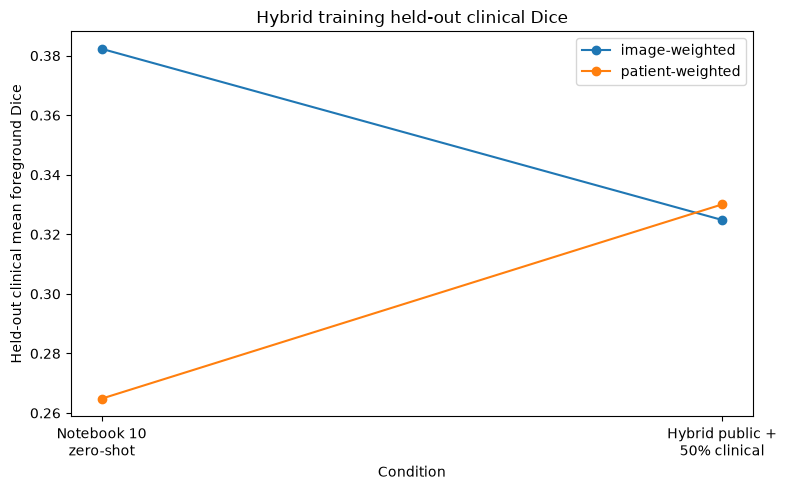

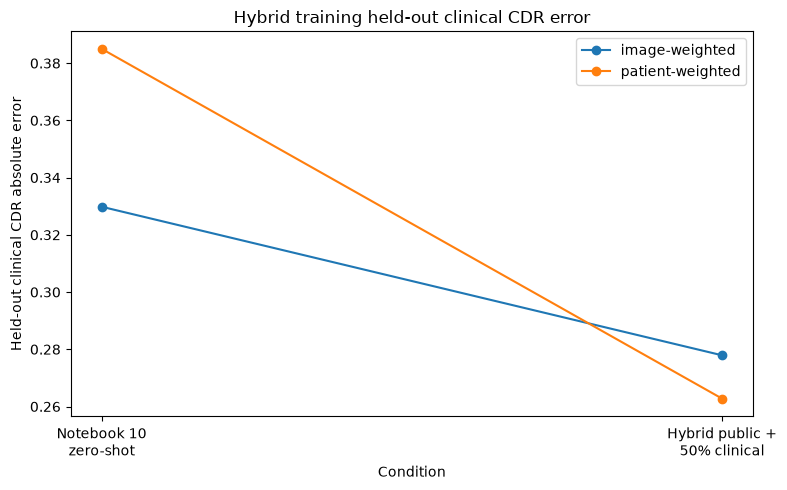

In [17]:
# 13.17 — Hybrid comparison visualization

plot_frame = comparison.copy()
plot_frame["label"] = plot_frame["condition"].replace(
    {
        ZERO: "Notebook 10\nzero-shot",
        HYBRID: "Hybrid public +\n50% clinical",
    }
)

plt.figure(figsize=(8, 5))
plt.plot(plot_frame["label"], plot_frame["image_weighted_mean_foreground_dice_mean"], marker="o", label="image-weighted")
plt.plot(plot_frame["label"], plot_frame["patient_weighted_mean_foreground_dice_mean"], marker="o", label="patient-weighted")
plt.xlabel("Condition")
plt.ylabel("Held-out clinical mean foreground Dice")
plt.title("Hybrid training held-out clinical Dice")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(plot_frame["label"], plot_frame["image_weighted_cdr_abs_error_mean"], marker="o", label="image-weighted")
plt.plot(plot_frame["label"], plot_frame["patient_weighted_cdr_abs_error_mean"], marker="o", label="patient-weighted")
plt.xlabel("Condition")
plt.ylabel("Held-out clinical CDR absolute error")
plt.title("Hybrid training held-out clinical CDR error")
plt.legend()
plt.tight_layout()
plt.show()
